In [1]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

import matplotlib.pyplot as plt

# Custom palette from your poster
poster_colors = ['#2D5A82', '#A6192E', '#4A90E2', "#632797", "#31743C"]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=poster_colors)
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['axes.edgecolor'] = '#2D5A82' # Uses the header blue for the plot frame


All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [2]:
#input parameters

theta_status = False
theta_freq = 8.0
g_max = 0.005
g_min = 0.0005
mod_depth = 0.05

tau_fall = 800.0 #ms
tau_rise = 400.0 #ms

dc_current = -2.7e-4

field_size = 4000 #ms
bw_field_size = 4000 #ms


In [3]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import fake_stellate
import stellate
import interneuron_amb
import importlib
importlib.reload(fake_stellate)
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

0.0

In [4]:
stellate_0 = stellate.Stellate(0)
interneuron_0 = interneuron_amb.Interneuron(0)

In [5]:
stell_ic_0 = h.IClamp(stellate_0.soma(0.5))
stell_ic_0.dur = 1e9

sim_dur = 10000 #in ms
num_steps = int(sim_dur/h.dt)
time_arr = np.arange(0,sim_dur,h.dt)

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
stellate_gnap_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gna)
nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



In [6]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 10.0


n_points = len(time_arr)

stell_ic = h.IClamp(stellate_0.soma(0.5))
stell_ic.dur = 1e9
dc_val = -3e-4
inhib_dc = np.full(n_points,dc_val,dtype=np.float64)
stell_dc_vec = h.Vector(inhib_dc)
stell_dc_vec.play(stell_ic._ref_amp,h.dt)

Vector[5]

In [649]:
g_max = 0.0005 #2.92e-4
g_min = 0.00005 #2.40e-6
mod_depth = 0.05
init_phase = np.random.uniform(0,2*np.pi)
print(init_phase)

idx_1 = int(2000/h.dt)
idx_2 = int(6500/h.dt)
idx_3 = int(6500/h.dt)

inhib_base = np.full(n_points,g_max)
t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
inhib_base[idx_1:idx_2] = (g_max-g_min)*(np.exp(-t_phase1/tau_fall)) + g_min
inhib_base[idx_2:idx_3] = inhib_base[idx_2-1]
t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
start_val = inhib_base[idx_3 - 1]
inhib_base[idx_3:] = (start_val + (g_max-start_val)*(1-np.exp(-t_phase3/tau_rise)))
#inhib_base[idx_3:] = start_val*np.exp(t_phase3/tau_rise)
#inhib_base[idx_3:] = np.full_like(inhib_base[idx_3:],1e-3)
theta_factor = 1 + (mod_depth*(np.sin(init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))


# --- Gaussian Disinhibition (Predictive Priming) ---
t_mid = 4000.0  # Center of the grid field
width = 2500.0  # Spatial/Temporal width of the field

# Gaussian disinhibition: Inhibition is highest far from the center
# and drops (disinhibits) as you approach t_mid.
dist_from_center = (time_arr - t_mid)
inhib_envelope = g_max - (g_max - g_min) * np.exp(-(dist_from_center**2) / (2 * width**2))

# Apply multiplicative theta modulation
#inhib_cond_arr = inhib_envelope * theta_factor

inhib_cond_arr = inhib_base * theta_factor
noise = np.random.normal(loc=0.0,scale=5e-6,size=len(inhib_cond_arr))
inhib_cond_arr += noise
inhib_cond_arr = np.maximum(inhib_cond_arr,0.000001)

g_vec = h.Vector(inhib_cond_arr)
g_vec.play(syn_inh._ref_g, h.dt)
g_rec = h.Vector().record(syn_inh._ref_g)



0.9346928204244667


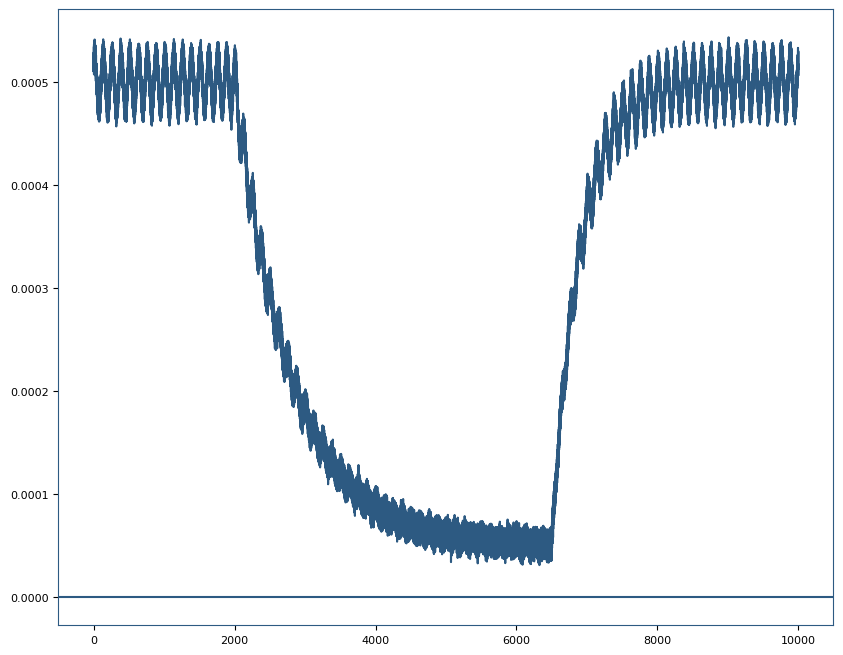

In [650]:
plt.figure(figsize=(10,8))
plt.plot(time_arr,inhib_cond_arr)
plt.axhline(y=0.0)
#plt.xlim(3800,4500)

In [651]:
h.finitialize(-80)
h.frecord_init()
h.continuerun(sim_dur)

0.0

In [652]:
#phase extraction

spikes_arr = np.array(spike_times_stell.to_python())
phases = ((init_phase+((spikes_arr) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))
phases_shifted = phases + 2*np.pi

0 400000


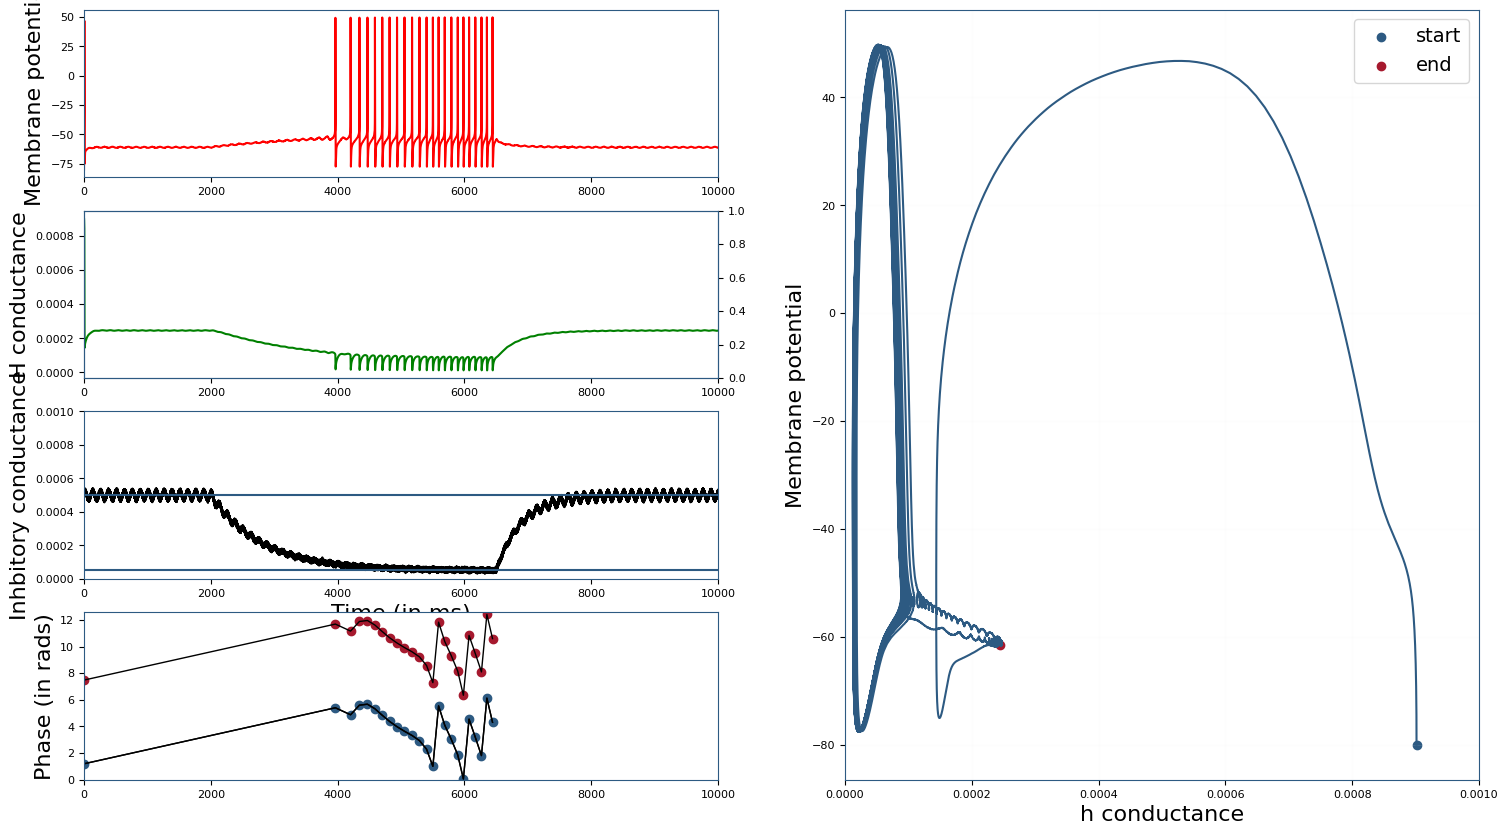

In [653]:
from matplotlib.gridspec import GridSpec

gh_cond = stellate_gh_vec.to_python()
gnap_cond = stellate_gnap_vec.to_python()
memb_pot = stell_v.to_python()
start_time = 0
end_time =  10000
start_idx = int(start_time/h.dt)
end_idx = int(end_time/h.dt)
print(start_idx,end_idx)
fig = plt.figure(figsize=(18,10))

gs = GridSpec(4,2,width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax1_1 = ax1.twinx()
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])


ax1.plot(time_arr[start_idx:end_idx],gh_cond[start_idx:end_idx],color='green')
ax2.set_xlabel("Time (in ms)")
ax2.set_ylabel("Inhbitory conductance")
ax1.set_ylabel("H conductance")
#ax1_1.plot(time_arr[start_idx:end_idx],gnap_cond[start_idx:end_idx],color='purple')
ax0.set_ylabel("Membrane potential")
ax0.plot(time_arr[start_idx:end_idx],memb_pot[start_idx:end_idx],color='red')
ax2.plot(time_arr[start_idx:end_idx],inhib_cond_arr[start_idx:end_idx],color='black')
ax2.axhline(y=g_max)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax2.axhline(y=g_min)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax3.plot(spikes_arr,phases_shifted,linewidth=1,color='black')
ax3.scatter(spikes_arr,phases)
ax3.scatter(spikes_arr,phases_shifted)
ax3.set_ylabel("Phase (in rads)")
ax3.set_ylim(0,4*np.pi)
ax_phase.plot(gh_cond[start_idx:end_idx],memb_pot[start_idx:end_idx])
ax_phase.scatter(gh_cond[start_idx],memb_pot[start_idx],label='start')
ax_phase.scatter(gh_cond[end_idx],memb_pot[end_idx],label='end')
ax_phase.legend()
ax_phase.set_xlabel("h conductance")
ax_phase.set_ylabel("Membrane potential")
ax_phase.set_xlim(0,0.001)
ax0.set_xlim(start_time,end_time)
ax1.set_xlim(start_time,end_time)
ax2.set_xlim(start_time,end_time)
ax3.set_xlim(start_time,end_time)
theta_status = ""
ax2.set_ylim(0,0.001)
plt.suptitle(f"")
plt.grid(True)

plt.show()





(0.0, 50.0)

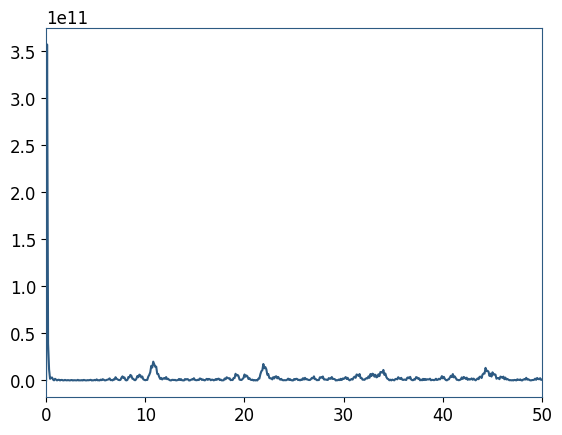

In [271]:
import analysis_utils as a_utils

fft_freq,fft_sig,psd = a_utils.calc_fft(memb_pot[start_idx:end_idx])
plt.plot(fft_freq,psd)
plt.xlim(0,50)


<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_46710/119017569.py:59: SyntaxWarning: invalid escape sequence '\m'
  ax_gh.set_ylabel("$g_h$ ($\mu$S/cm²)", color=color_gh, fontweight='bold')


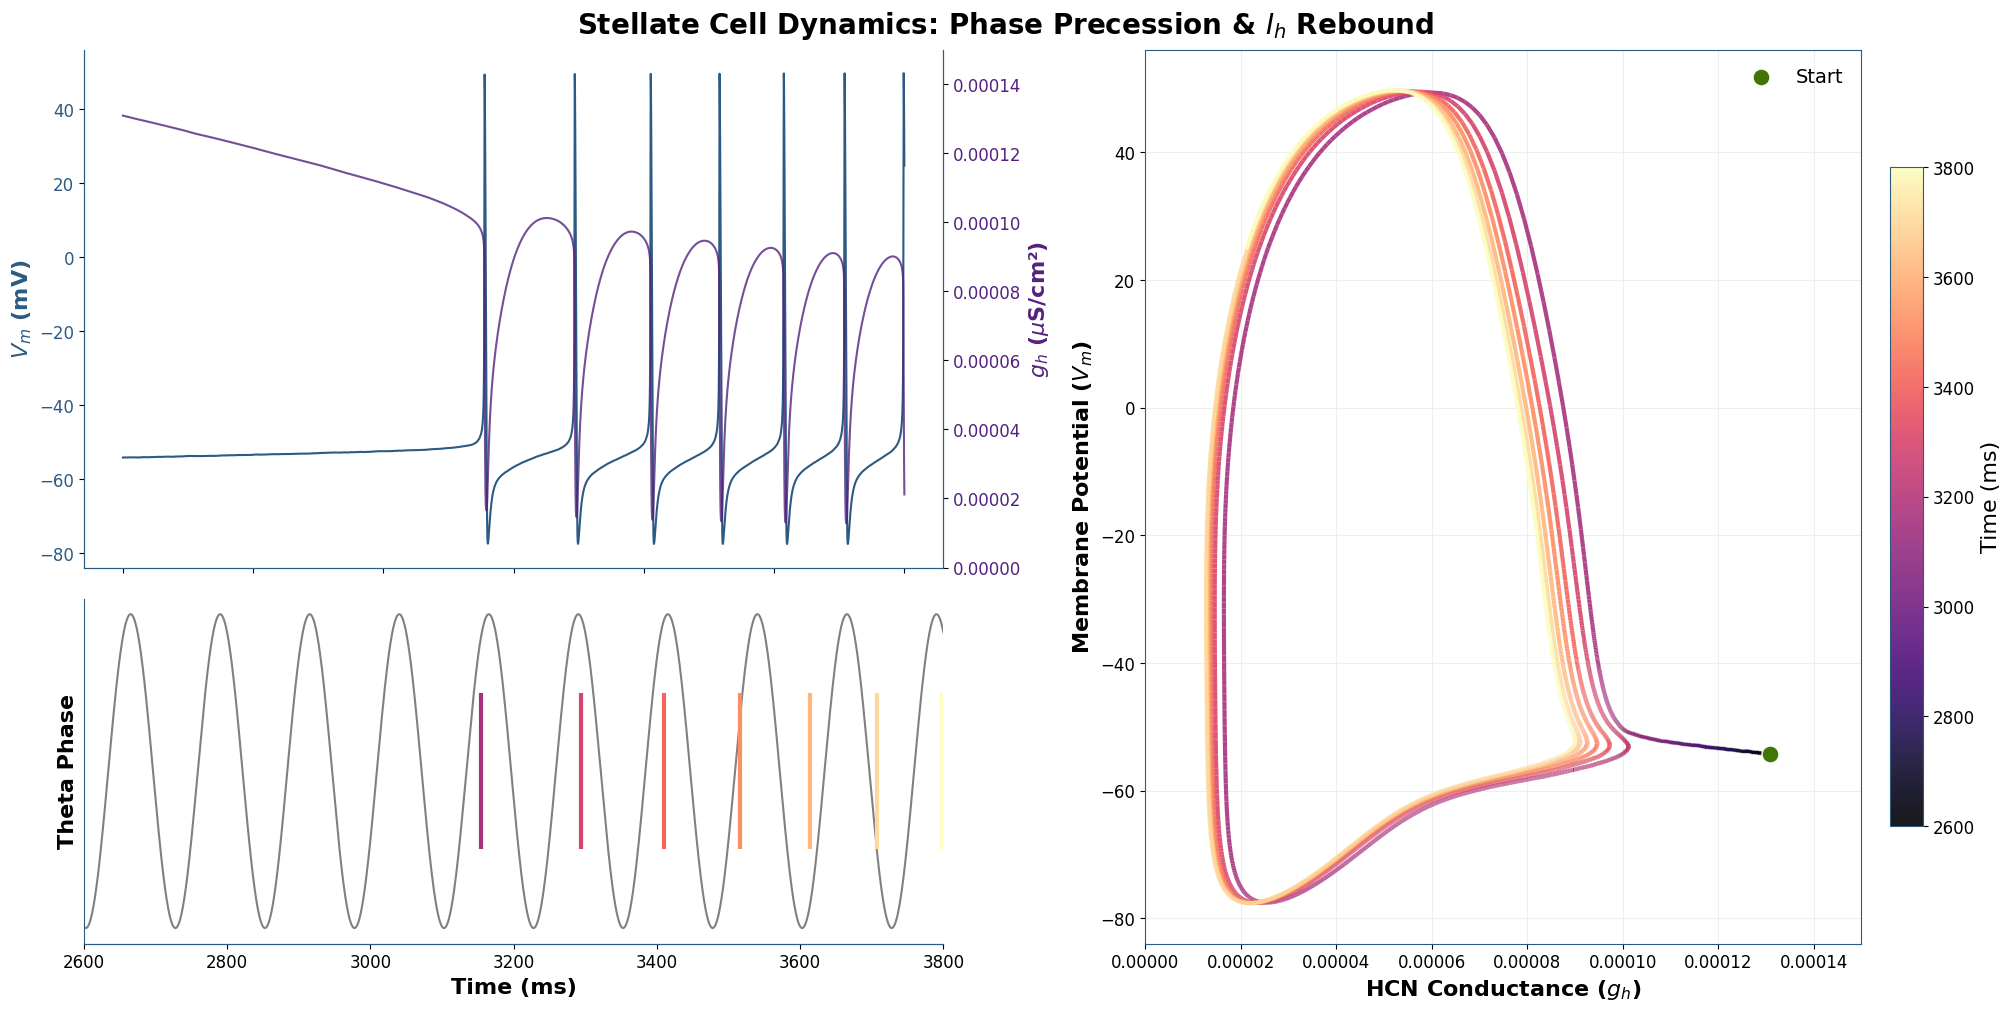

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection

# 1. Aesthetic Configuration
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.edgecolor': '#2D5A82',
    'grid.alpha': 0.1
})

# 2. Windowing and Data Preparation
start_time, end_time = 2600, 3800
start_idx = int(start_time / h.dt)
end_idx = int(end_time / h.dt)

t_win = time_arr[start_idx:end_idx]
v_win = memb_pot[start_idx:end_idx]
gh_win = gh_cond[start_idx:end_idx]

# Signal and Spike Extraction
theta_signal = np.sin(init_phase + (2 * np.pi * theta_freq * t_win / 1000.0))
window_spikes = [s for s in spike_times_stell.to_python() if start_time <= s <= end_time]

# Color Mapping
norm = plt.Normalize(start_time, end_time)
cmap = plt.get_cmap('magma') # 'plasma' provides better contrast than 'Purples' for posters
spike_colors = [cmap(norm(s)) for s in window_spikes]
spike_positions = [[s] for s in window_spikes]

# 3. Figure Layout
fig = plt.figure(figsize=(20, 10), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig, width_ratios=[1.2, 1], height_ratios=[1.5, 1])

# Left side: Top is Dual-Axis, Bottom is Theta/Spikes
ax_dual = fig.add_subplot(gs[0, 0])
ax_theta = fig.add_subplot(gs[1, 0])
# Right side: Phase Portrait
ax_phase = fig.add_subplot(gs[:, 1])

# --- 4. Subplot: Dual Time Series (Vm and gh) ---
color_v = '#2D5A82'
color_gh = "#53227E"

# Primary Y-axis: Membrane Potential
ax_dual.plot(t_win, v_win, color=color_v, linewidth=1.5, label='$V_m$')
ax_dual.set_ylabel("$V_m$ (mV)", color=color_v, fontweight='bold')
ax_dual.tick_params(axis='y', labelcolor=color_v)_
ax_dual.set_xticklabels([]) # Stacked look

# Secondary Y-axis: HCN Conductance
ax_gh = ax_dual.twinx()
ax_gh.plot(t_win, gh_win, color=color_gh, linewidth=1.5, alpha=0.8, label='$g_h$')
ax_gh.set_ylabel("$g_h$ ($\mu$S/cm²)", color=color_gh, fontweight='bold')
ax_gh.tick_params(axis='y', labelcolor=color_gh)
ax_gh.set_ylim(0, 0.00015)

ax_dual.spines['top'].set_visible(False)
ax_gh.spines['top'].set_visible(False)

# --- 5. Subplot: Theta and Colored Spikes ---
ax_theta.plot(t_win, theta_signal, color='gray', alpha=1)
ax_theta.set_ylabel("Theta Phase", fontweight='bold')
ax_theta.set_xlabel("Time (ms)", fontweight='bold')
ax_theta.set_xlim(start_time, end_time)
ax_theta.set_yticks([])

ax_ev = ax_theta.twinx()
ax_ev.eventplot(spike_positions, orientation='horizontal', 
                lineoffsets=0, linelengths=0.9, 
                colors=spike_colors, linewidth=3)
ax_ev.set_ylim(-1, 1)
ax_ev.set_yticks([])
ax_ev.spines[['top', 'right', 'left']].set_visible(False)
ax_theta.spines[['top', 'right']].set_visible(False)

# --- 6. Subplot: Phase Portrait ---
points = np.array([gh_win, v_win]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=3, alpha=0.9)
lc.set_array(t_win)
line = ax_phase.add_collection(lc)

ax_phase.scatter(gh_win[0], v_win[0], s=150, color='#417505', label='Start', zorder=5, edgecolor='white')

ax_phase.set_xlabel("HCN Conductance ($g_h$)", fontweight='bold')
ax_phase.set_ylabel("Membrane Potential ($V_m$)", fontweight='bold')
ax_phase.set_xlim(0, 0.00015) 
ax_phase.grid(True, linestyle='-', alpha=1)
ax_phase.legend(frameon=False)

cbar = fig.colorbar(line, ax=ax_phase, fraction=0.046, pad=0.04)
cbar.set_label('Time (ms)')

plt.suptitle("Stellate Cell Dynamics: Phase Precession & $I_h$ Rebound", 
             fontweight='bold', fontsize=20, color='black')
plt.savefig("final_figs/stell_cell_dynamics_1.png",dpi=600)
plt.show()

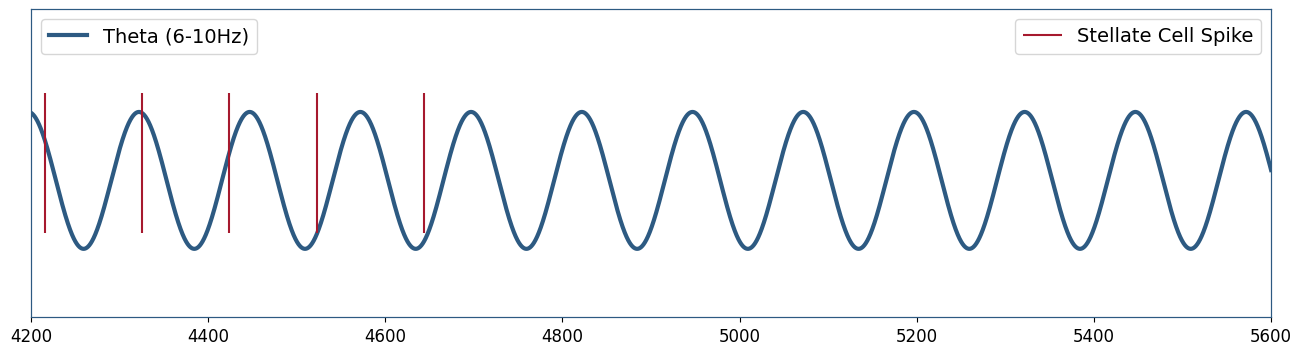

In [158]:
#PHASE PRECESSION SCHEMATIC
fig,ax = plt.subplots(figsize=(16,4))
ax1=ax.twinx()
ax.plot(time_arr,theta_factor,linewidth=3,label='Theta (6-10Hz)')
ax1.eventplot(spikes_arr,linelengths=0.5,color='C1',label='Stellate Cell Spike')
ax.set_ylim(0.8,1.25)
ax.set_yticks([])
ax1.set_yticks([])
ax1.legend()
ax.legend(loc='upper left')
plt.xlim(4200,5600)
plt.grid(True)
plt.savefig("final_figs/pp_schematic.png",dpi=600)


In [159]:
print(np.diff(spikes_arr))

[3014.42499999  235.5         125.25        117.825       115.825
  115.45        107.825        81.25         83.4         101.95
  112.675       109.7          97.65         99.925       120.225     ]


(0.0, 6.283185307179586)

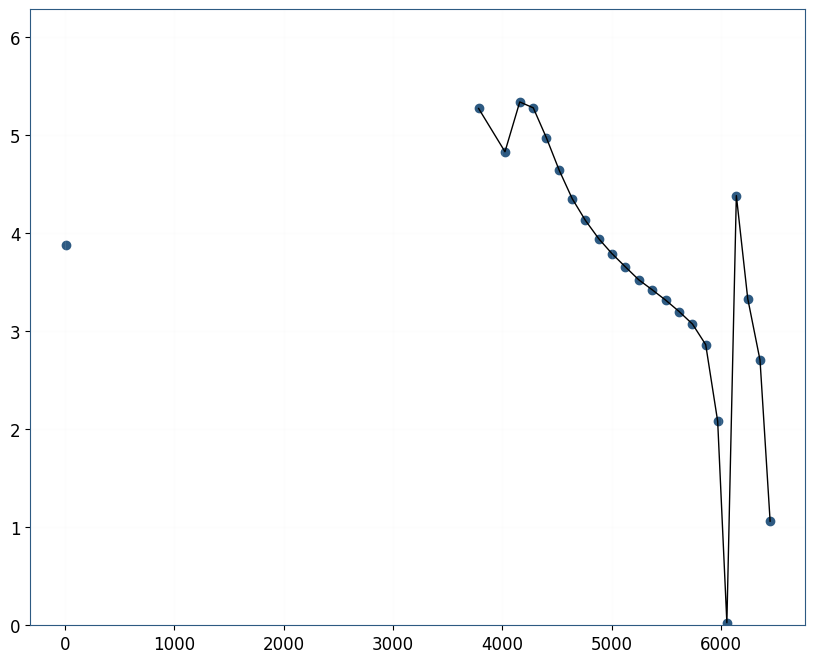

In [291]:
plt.figure(figsize=(10,8))
plt.scatter(spikes_arr,phases)
plt.plot(spikes_arr[1:],phases[1:],linewidth=1,color='black')
plt.grid(True)

plt.ylim(0,2*np.pi)


In [7]:
# Print the current ghbar value
print(f"Current ghbar: {stellate_0.soma(0.5).stellate_mech.ghbar}")

Current ghbar: 0.0015


In [8]:
num_runs = 20
spike_times_matrix = []
spike_phases_matrix =[]

gauss = True
theta = True
stellate_0.soma(0.5).stellate_mech.ghbar = 0.0015
for n in range(num_runs):

    cond_arr = np.full_like(time_arr,0.0)
    spike_times_stell.resize(0)

    curr_init_phase = np.random.uniform(0.0,2*np.pi)
    
    theta_factor = 1 + (mod_depth*(np.sin(curr_init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))

    if gauss:
        cond_arr = inhib_envelope 
    else : 
        cond_arr = inhib_base

    
    if theta:   
        cond_arr = cond_arr * theta_factor

    noise = np.random.normal(loc=0.0,scale=5e-6,size=len(inhib_cond_arr))
    
    cond_arr += noise
    cond_arr = np.maximum(cond_arr,0.00001)
    g_vec = h.Vector(cond_arr)
    g_vec.play(syn_inh._ref_g, h.dt)

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(sim_dur)

    temp_spikes = np.array(spike_times_stell.to_python())
    temp_phases = ((curr_init_phase+((temp_spikes) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

    spike_times_matrix.append(temp_spikes)
    spike_phases_matrix.append(temp_phases)

    spike_times_stell.resize(0)

NameError: name 'inhib_envelope' is not defined

In [508]:
#first spike time
from scipy import stats

# 1. Collect the first spike phase from each of the 20 runs
# We use radians for the actual calculation to stay consistent with Scipy
initial_phases_rad = []

for i in range(20):
    if len(spike_phases_matrix[i]) > 0:
        initial_phases_rad.append(spike_phases_matrix[i][0])

initial_phases_rad = np.array(initial_phases_rad)

# 2. Calculate Circular Mean and Standard Deviation
# Using high/low limits of 0 to 2*pi for radians
mean_rad = stats.circmean(initial_phases_rad, low=0, high=2*np.pi)
std_rad = stats.circstd(initial_phases_rad, low=0, high=2*np.pi)

# 3. Convert to Degrees for your Poster text
mean_deg = np.degrees(mean_rad)
std_deg = np.degrees(std_rad)

print(f"Mean Entry Phase: {mean_deg:.2f}°")
print(f"Phase Variability (Circular SD): {std_deg:.2f}°")

Mean Entry Phase: 309.15°
Phase Variability (Circular SD): 19.31°


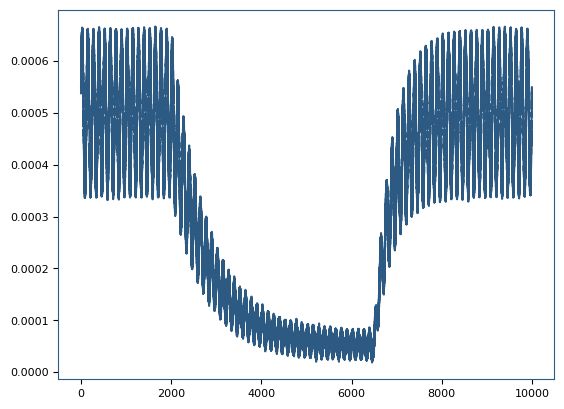

In [599]:
plt.plot(time_arr,inhib_cond_arr)

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_46710/389333487.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel('Inhibitory Conductance $\mu S$\cm2',fontsize=10)


304.74046735747544 664.7404673574754
2783.024999994663
311.74578243988134 671.7457824398814
2757.12499999504
299.3691985863692 659.3691985863692
2837.52499999387
298.26862109422626 658.2686210942263
2798.3999999944394
303.5351553249495 663.5351553249495
2782.224999994675
297.3725571507728 657.3725571507728
2787.1249999946035
314.2811239780295 674.2811239780294
2760.4749999949913
296.0977080869919 656.0977080869918
2826.9249999940243
351.4913069379573 711.4913069379572
2733.7999999953795
303.0173302272963 663.0173302272963
2791.3749999945417
322.64927832120446 682.6492783212045
2742.02499999526
292.1401991112468 652.1401991112468
2816.8249999941713
307.13177814300155 667.1317781430016
2768.949999994868
327.6421058855201 687.6421058855201
2740.224999995286
320.43234978881173 680.4323497888117
2744.74999999522
324.22817889257317 684.2281788925732
2747.224999995184
295.26723876432266 655.2672387643227
2802.9499999943732
302.59858818227286 662.5985881822728
2788.8999999945777
294.2381370344

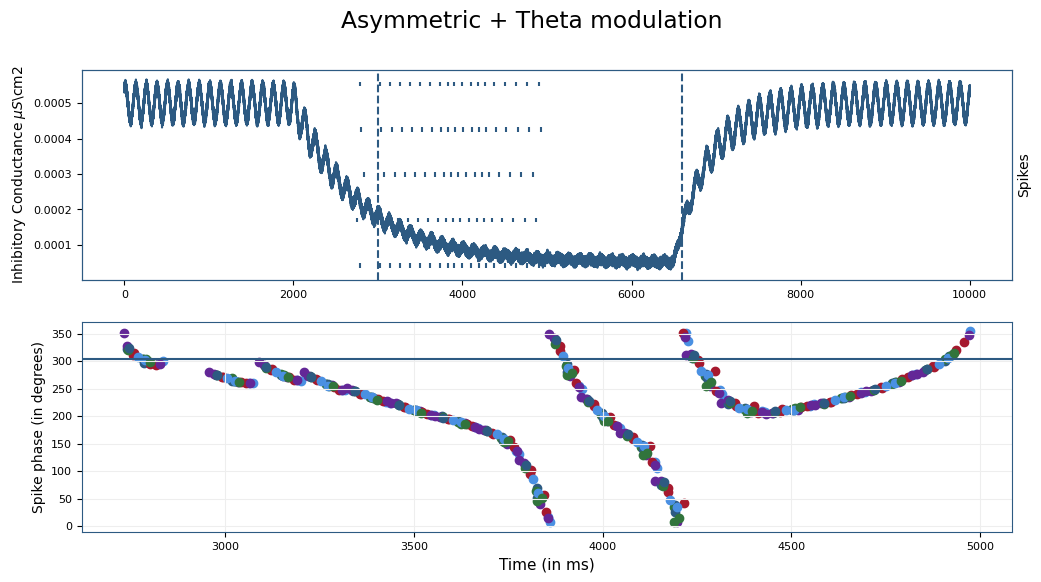

In [603]:
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.edgecolor': '#2D5A82',
    'grid.alpha': 0.1
})

fig,ax = plt.subplots(2,1,figsize=(12,6))

for i in range(20):
    times = spike_times_matrix[i]
    phases = spike_phases_matrix[i]
    ax[1].scatter(times,np.degrees(phases))
    #plt.axhline(y=np.degrees(phases[0]))
    #plt.axhline(y=np.degrees(phases[0])+360)
    #plt.scatter(times,np.degrees(phases)+360.0)
    #ax[1].plot(times,np.degrees(phases),linewidth=1.5)
    print(np.degrees(phases[0]),np.degrees(phases[0])+360)
    print(times[0])
    
plt.axhline(np.degrees(spike_phases_matrix[0][0]))
#plt.axhline(np.degrees(spike_phases_matrix[0][0])+360)
ax[1].grid(True,alpha=1)
ax[0].plot(time_arr,inhib_cond_arr)

ax[0].axvline(x=3000,ls='--')
ax[0].axvline(x=6600,ls='--')
ax2=ax[0].twinx()
ax2.eventplot(spike_times_matrix[:5],linelengths=0.1)
plt.suptitle("Asymmetric + Theta modulation")
plt.xlabel("Time(in ms)")
ax[1].set_ylabel("Spike phase (in degrees)",fontsize=10)
ax[0].set_ylabel('Inhibitory Conductance $\mu S$\cm2',fontsize=10)
ax2.set_yticks([])
ax2.set_ylabel("Spikes",fontsize=10)
ax[1].set_xlabel("Time (in ms)",fontsize=11)
plt.savefig("final_figs/mult_runs_asym_yestheta_mod.png",dpi=600)

In [333]:
import analysis_utils as a_utils
from scipy.stats import linregress

fields = a_utils.separate_fields(spike_times_matrix)
print(fields)

shifted_fields = a_utils.shift_fields_to_center(spike_times_matrix)
print(shifted_fields)

{0: [[3252.4249999878325, 3370.1249999861197, 3486.3999999844277, 3602.324999982741, 3718.5999999810488, 3811.424999979698, 3890.1499999785524, 3983.1249999771994, 4087.1499999756857, 4171.949999974452, 4255.3499999732385], [4750.574999966032, 4889.52499996401]], 1: [[3287.3249999873246, 3521.7999999839126, 3641.274999982174, 3755.3249999805143, 3846.9999999791803, 3925.37499997804, 4019.149999976675, 4124.324999975145, 4212.1249999738675, 4295.674999972652], [4792.799999965418, 4931.224999963403]], 2: [[3089.374999990205, 3207.8249999884815, 3323.9749999867913, 3438.2499999851284, 3556.7749999834036, 3673.499999981705, 3777.2499999801953, 3855.899999979051, 3941.3249999778077, 4044.24999997631, 4134.874999974992, 4215.824999973814], [4696.42499996682, 4833.449999964826]], 3: [[3287.099999987328, 3403.9499999856275, 3521.6749999839144, 3637.6499999822267, 3751.974999980563, 3841.049999979267, 3920.9249999781046, 4016.974999976707, 4120.974999975194, 4203.72499997399, 4289.474999972742]

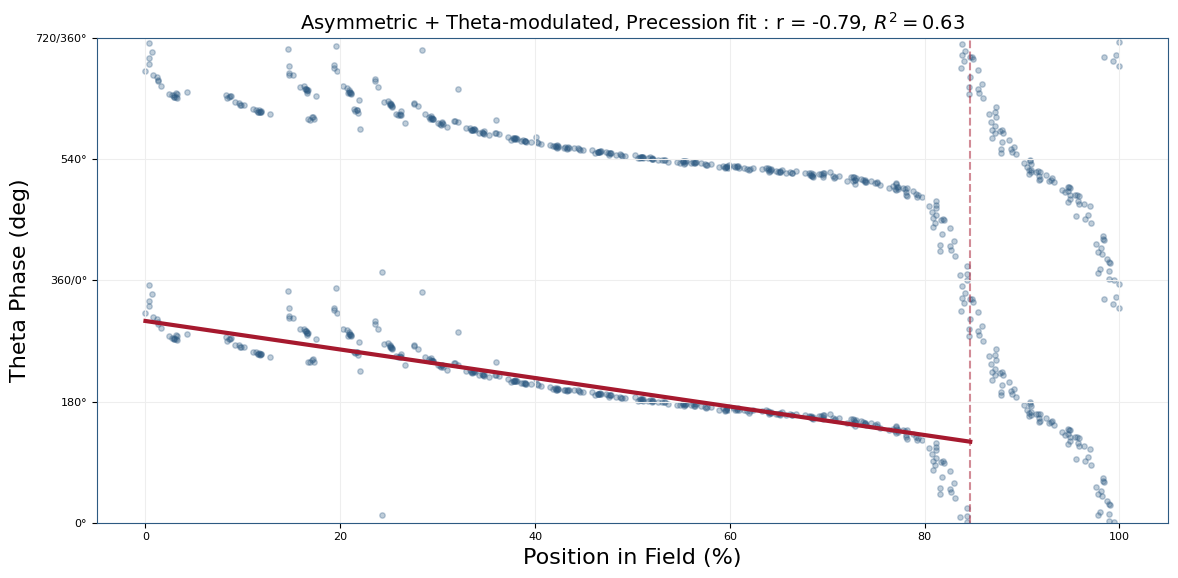

In [491]:
import numpy as np3
import matplotlib.pyplot as plt
from scipy.stats import linregress

def calculate_precession_stats(all_spike_times, all_spike_phases, t_start=2000, t_end=6500, t_fit=6060):
    # 1. Filter spikes in the broad window
    mask = (all_spike_times >= t_start) & (all_spike_times <= t_end)
    field_spikes = all_spike_times[mask]
    field_phases_raw = np.degrees(all_spike_phases[mask]) 
    
    if len(field_spikes) == 0:
        print("No spikes found in window.")
        return None, None, None

    # 2. Reference points for normalization (Data-driven 0% to 100%)
    # This makes the first spike exactly 0 and the last spike exactly 100
    t_min = np.min(field_spikes)
    t_max = np.max(field_spikes)
    norm_pos = (field_spikes - t_min) / (t_max - t_min) * 100
    
    # 3. Identify the subset to be used for the FIT
    fit_mask = (field_spikes <= t_fit)
    x_fit = norm_pos[fit_mask]
    p_fit = field_phases_raw[fit_mask]
    
    best_r2 = -1
    stats = {}

    # 4. Hafting Circular Rotation with NEGATIVE slope constraint
    for shift in range(360):
        shifted_phases = (p_fit + shift) % 360
        slope, intercept, r_val, p_val, _ = linregress(x_fit, shifted_phases)
        
        if slope < 0:
            r2 = r_val**2
            if r2 > best_r2:
                best_r2 = r2
                stats = {
                    'slope': slope,
                    'r2': r2,
                    'r': r_val,
                    'best_shift': shift,
                    'intercept': intercept,
                    't_fit_percent': (t_fit - t_min) / (t_max - t_min) * 100
                }
    
    if not stats:
        print("Warning: No negative slope found. Check t_fit value.")
        return None, norm_pos, field_phases_raw
            
    return stats, norm_pos, field_phases_raw

def plot_precession_fit(norm_pos, raw_phases, stats):
    if stats is None: return
    
    # Align phases using the shift found in the fit
    aligned_phases = (raw_phases + stats['best_shift']) % 360
    
    plt.figure(figsize=(12, 6))
    
    # Plotting the raw spikes (double cycle for continuity)
    # Using 'label="_nolegend_"' to avoid the duplicate legend entry issue you had
    plt.scatter(norm_pos, aligned_phases, color='#2D5A82', alpha=0.3, s=15, label='Spikes (Full Field)')
    plt.scatter(norm_pos, aligned_phases + 360, color='#2D5A82', alpha=0.3, s=15, label="_nolegend_")
    
    # Generate the fit line
    x_line = np.linspace(0, stats['t_fit_percent'], 100)
    y_line = stats['slope'] * x_line + stats['intercept']
    
    # --- CRITICAL FIX: Ensure the line is in the correct cycle ---
    # If the line is too low, we shift it up by 360 to match the data cloud
    if np.mean(y_line) < 180 and np.mean(aligned_phases[norm_pos <= stats['t_fit_percent']]) > 300:
        y_line += 360

    plt.plot(x_line, y_line, color='#A6192E', linewidth=3, 
             label=f"Primary Fit ($r$={stats['r']:.2f})")
    
    # Boundary Marker
    plt.axvline(stats['t_fit_percent'], color='#A6192E', linestyle='--', alpha=0.5)
    
    # Formatting
    plt.title(f"Asymmetric + Theta-modulated, Precession fit : r = {stats['r']:.2f}, $R^2 = ${stats['r2']:.2f}", fontsize=14)
    plt.xlabel("Position in Field (%)")
    plt.ylabel("Theta Phase (deg)")
    plt.ylim(0, 720)
    plt.yticks([0, 180, 360, 540, 720], ["0°", "180°", "360/0°", "540°", "720/360°"])
    #plt.legend(frameon=False, loc='upper right')
    plt.grid(True, alpha=1)
    plt.tight_layout()
    plt.savefig("final_figs/asym_yesthetamod_hafting_fit.png",dpi=600)
    plt.show()
pooled_times = np.concatenate(spike_times_matrix)
pooled_phases = np.concatenate(spike_phases_matrix)
# Run
stats, n_pos, r_phases = calculate_precession_stats(pooled_times, pooled_phases)
plot_precession_fit(n_pos, r_phases, stats)

In [ ]:



dt = h.dt
n_points = len(time_arr)

idx_1 = int(2000 / dt)  # Start of decay (entering field)
idx_2 = int(6000 / dt)  # End of decay
idx_3 = int(6500 / dt)  # Start of rise (exiting field)

g_max = 0.0005
g_min = 0.00005
tau_rise = 100          # Ensure tau_rise is defined for the recovery phase

# Sensitivity Range
tf_array = np.arange(500, 1000, 50) 
tf_spike_times_matrix = []
tf_spike_phases_matrix = []

stellate_0.soma(0.5).stellate_mech.ghbar = 0.0015 

print(f"Executing sweep for tau_fall: {tf_array}")

for n in range(len(tf_array)):
    # --- STEP 1: Construct the Conductance Trace ---
    # Use one consistent local variable (local_cond) to avoid naming bugs
    local_cond = np.full(n_points, g_max)
    tau_fall_temp = tf_array[n]
    
    # Phase 1: Exponential Decay (Disinhibition)
    t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
    local_cond[idx_1:idx_2] = (g_max - g_min) * (np.exp(-t_phase1 / tau_fall_temp)) + g_min
    
    # Phase 2: Plateau (The "Bottom" of the field)
    local_cond[idx_2:idx_3] = local_cond[idx_2 - 1]
    
    # Phase 3: Exponential Rise (Re-inhibition)
    t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
    start_val = local_cond[idx_3 - 1]
    local_cond[idx_3:] = (start_val + (g_max - start_val) * (1 - np.exp(-t_phase3 / tau_rise)))

    # --- STEP 2: Apply Theta Modulation and Noise ---
    curr_init_phase = np.random.uniform(0.0, 2 * np.pi)
    theta_factor = 1 + (0.1 * (np.sin(curr_init_phase + (2 * np.pi * theta_freq * time_arr / 1000.0))))
    
    # Apply theta and add noise correctly using time_arr length
    local_cond *= theta_factor
    noise = np.random.normal(loc=0.0, scale=5e-6, size=n_points)
    local_cond = np.maximum(local_cond + noise, 0.00001)

    # --- STEP 3: Run NEURON Simulation ---
    g_vec = h.Vector(local_cond)
    g_vec.play(syn_inh._ref_g, h.dt)

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(sim_dur)

    # --- STEP 4: Data Extraction ---
    temp_spikes = np.array(spike_times_stell.to_python())
    # Calculate phases in radians relative to the theta rhythm
    temp_phases = ((curr_init_phase + (temp_spikes * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

    tf_spike_times_matrix.append(temp_spikes)
    tf_spike_phases_matrix.append(temp_phases)

    # Reset spike vector for next run
    spike_times_stell.resize(0)

print("Sensitivity analysis complete.")

Executing sweep for tau_fall: [500 550 600 650 700 750 800 850 900 950]
Sensitivity analysis complete.


In [20]:
print(tf_array)
print(tf_spike_phases_matrix)

[500 550 600 650 700 750 800 850 900 950]
[array([5.25894800e+00, 4.63188611e+00, 4.86562060e+00, 4.64947903e+00,
       4.34285959e+00, 4.01613395e+00, 3.76480654e+00, 3.55997470e+00,
       3.41923134e+00, 3.26969153e+00, 3.06234642e+00, 2.73562078e+00,
       1.34075364e+00, 5.38586835e+00, 3.78491273e+00, 2.94799245e+00,
       1.55061203e+00, 5.53917807e+00, 3.84648794e+00, 2.91531988e+00,
       1.28671825e+00, 5.23507190e+00, 3.59767381e+00, 2.68409866e+00,
       8.12966078e-01, 4.81661176e+00, 3.36268268e+00, 2.26563852e+00,
       3.69181041e-03, 4.23730207e+00, 3.02967385e+00, 1.55186867e+00,
       5.50022232e+00]), array([5.39832787, 4.52370847, 4.71723058, 4.53124829, 4.23342531,
       3.9720448 , 3.76092978, 3.56740767, 3.39776166, 3.2633015 ,
       3.0396201 , 2.84358472, 1.85209808, 5.92611543, 4.12284125,
       3.15523071, 2.18887681, 0.02746107, 4.29248725, 3.14643425,
       2.05316001, 6.07188533, 4.13666426, 3.02831037, 1.61459367,
       5.53907122, 3.78731915

/tmp/ipykernel_164229/3549976233.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')
/tmp/ipykernel_164229/3549976233.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='upper right')


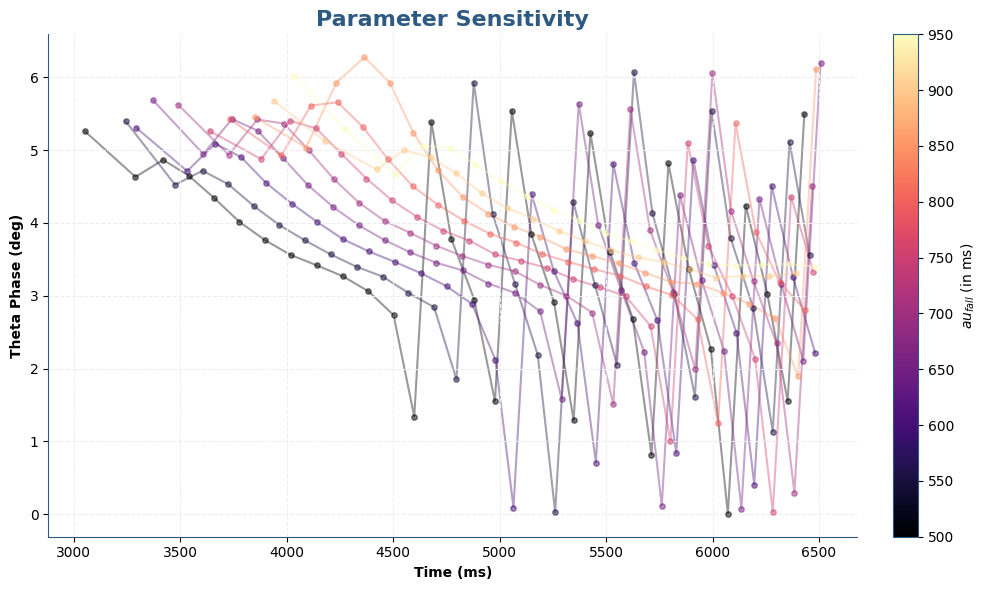

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Setup the Color Mapping
cmap = cm.get_cmap('magma')
norm = plt.Normalize(vmin=tf_array.min(), vmax=tf_array.max())
ref_scale = 1.0

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Iterate and Plot
for n in range(len(tf_array)):
    scale = tf_array[n]
    color = cmap(norm(scale))
    
    
    # Background Gradient Lines
    ax.plot(tf_spike_times_matrix[n], tf_spike_phases_matrix[n], 
                color=color, linewidth=1.5, alpha=0.4, zorder=1)
    ax.scatter(tf_spike_times_matrix[n], tf_spike_phases_matrix[n], 
                   color=color, s=15, alpha=0.5, zorder=2)

# 3. Add Colorbar for the gradient context
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$\tau_{fall}$ (in ms)')

# 4. Poster Aesthetics
ax.set_title("Parameter Sensitivity", 
             fontsize=16, fontweight='bold', color='#2D5A82')
ax.set_xlabel("Time (ms)", fontweight='bold')
ax.set_ylabel("Theta Phase (deg)", fontweight='bold')

ax.legend(frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=1)

plt.tight_layout()
plt.savefig("final_figs/hcn_sensitivity.png",dpi=600)
plt.show()

In [22]:
import numpy as np
from neuron import h
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
dt = h.dt
n_points = len(time_arr)
idx_1 = int(2000 / dt)  # Entering field (decay starts)
idx_2 = int(6000 / dt)  # End of decay
idx_3 = int(6500 / dt)  # Exiting field (rise starts)

# Fixed parameters for this sweep
tau_fall_ref = 800      # Using your working reference value
tau_rise = 100
g_min = 0.00005

# g_max Sensitivity Range (centered around your 0.0005 baseline)
g_max_array = np.linspace(0.0002, 0.001, 10) 
gm_spike_times_matrix = []
gm_spike_phases_matrix = []

# Ensure Ih density is at reference 
stellate_0.soma(0.5).stellate_mech.ghbar = 0.0015 

print(f"Executing sweep for g_max: {g_max_array}")

for n in range(len(g_max_array)):
    current_g_max = g_max_array[n]
    local_cond = np.full(n_points, current_g_max)
    
    # --- PHASE 1: Decay ---
    t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
    local_cond[idx_1:idx_2] = (current_g_max - g_min) * (np.exp(-t_phase1 / tau_fall_ref)) + g_min
    
    # --- PHASE 2: Plateau ---
    local_cond[idx_2:idx_3] = local_cond[idx_2 - 1]
    
    # --- PHASE 3: Rise ---
    t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
    start_val = local_cond[idx_3 - 1]
    local_cond[idx_3:] = (start_val + (current_g_max - start_val) * (1 - np.exp(-t_phase3 / tau_rise)))

    # --- THETA & NOISE ---
    curr_init_phase = np.random.uniform(0.0, 2 * np.pi)
    theta_factor = 1 + (0.1 * (np.sin(curr_init_phase + (2 * np.pi * theta_freq * time_arr / 1000.0))))
    local_cond *= theta_factor
    
    noise = np.random.normal(loc=0.0, scale=5e-6, size=n_points)
    local_cond = np.maximum(local_cond + noise, 0.00001)

    # --- SIMULATION ---
    g_vec = h.Vector(local_cond)
    g_vec.play(syn_inh._ref_g, h.dt)

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(sim_dur)

    # --- DATA EXTRACTION ---
    temp_spikes = np.array(spike_times_stell.to_python())
    temp_phases = ((curr_init_phase + (temp_spikes * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

    gm_spike_times_matrix.append(temp_spikes)
    gm_spike_phases_matrix.append(temp_phases)

    spike_times_stell.resize(0)

print("g_max sweep complete.")

Executing sweep for g_max: [0.0002     0.00028889 0.00037778 0.00046667 0.00055556 0.00064444
 0.00073333 0.00082222 0.00091111 0.001     ]
g_max sweep complete.


/tmp/ipykernel_164229/330628091.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')
/tmp/ipykernel_164229/330628091.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='upper right')


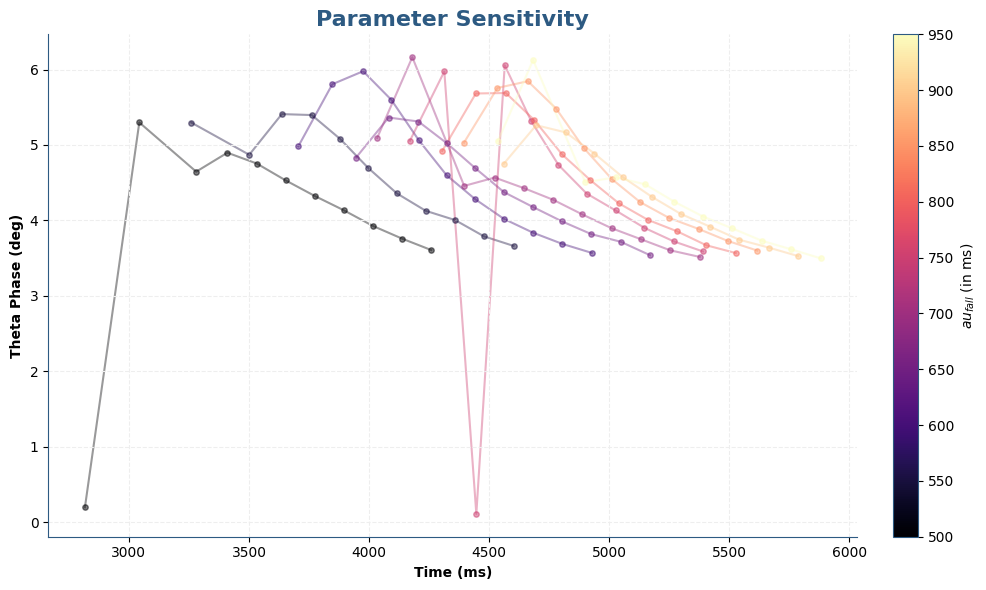

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Setup the Color Mapping
cmap = cm.get_cmap('magma')
norm = plt.Normalize(vmin=tf_array.min(), vmax=tf_array.max())
ref_scale = 1.0

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Iterate and Plot
for n in range(len(tf_array)):
    scale = tf_array[n]
    color = cmap(norm(scale))
    
    
    # Background Gradient Lines
    ax.plot(gm_spike_times_matrix[n][1:12], gm_spike_phases_matrix[n][1:12], 
                color=color, linewidth=1.5, alpha=0.4, zorder=1)
    ax.scatter(gm_spike_times_matrix[n][1:12], gm_spike_phases_matrix[n][1:12], 
                   color=color, s=15, alpha=0.5, zorder=2)

# 3. Add Colorbar for the gradient context
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$\tau_{fall}$ (in ms)')

# 4. Poster Aesthetics
ax.set_title("Parameter Sensitivity", 
             fontsize=16, fontweight='bold', color='#2D5A82')
ax.set_xlabel("Time (ms)", fontweight='bold')
ax.set_ylabel("Theta Phase (deg)", fontweight='bold')

ax.legend(frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=1)

plt.tight_layout()
plt.savefig("final_figs/hcn_sensitivity.png",dpi=600)
plt.show()

In [47]:
import numpy as np
from neuron import h
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- 1. CONFIGURATION ---
g_max_array = np.linspace(0.0003, 0.001, 4)  # n values for g_max
tf_array = np.arange(600, 1201, 200)           # m values for tau_fall
n_points = len(time_arr)
g_min = 0.00005  # Fixed reference disinhibition floor

results_matrix_gm = []

print(f"Running {len(g_max_array) * len(tf_array)} simulations for g_max vs tau_fall...")

for gm_val in g_max_array:
    for tf_val in tf_array:
        # Construct the trace
        local_cond = np.full(n_points, gm_val)
        
        # Phase 1: Decay (Disinhibition)
        t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
        local_cond[idx_1:idx_2] = (gm_val - g_min) * (np.exp(-t_phase1 / tf_val)) + g_min
        
        # Phase 2: Plateau & Phase 3: Rise
        local_cond[idx_2:idx_3] = local_cond[idx_2 - 1]
        t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
        start_val = local_cond[idx_3 - 1]
        local_cond[idx_3:] = (start_val + (gm_val - start_val) * (1 - np.exp(-t_phase3 / tau_rise)))

        # Theta & Noise
        curr_init_phase = np.random.uniform(0.0, 2 * np.pi)
        theta_factor = 1 + (0.1 * (np.sin(curr_init_phase + (2 * np.pi * theta_freq * time_arr / 1000.0))))
        local_cond = np.maximum((local_cond * theta_factor) + np.random.normal(0, 5e-6, n_points), 0.00001)

        # Run NEURON
        g_vec = h.Vector(local_cond)
        g_vec.play(syn_inh._ref_g, h.dt)
        h.finitialize(-65)
        h.continuerun(sim_dur)

        # Store Data
        spks = np.array(spike_times_stell.to_python())
        phases = ((curr_init_phase + (spks * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))
        
        results_matrix_gm.append({
            'g_max': gm_val,
            'tf': tf_val,
            'spikes': spks,
            'phases': phases
        })
        spike_times_stell.resize(0)

print("Matrix Sweep Complete.")

Running 16 simulations for g_max vs tau_fall...
Matrix Sweep Complete.


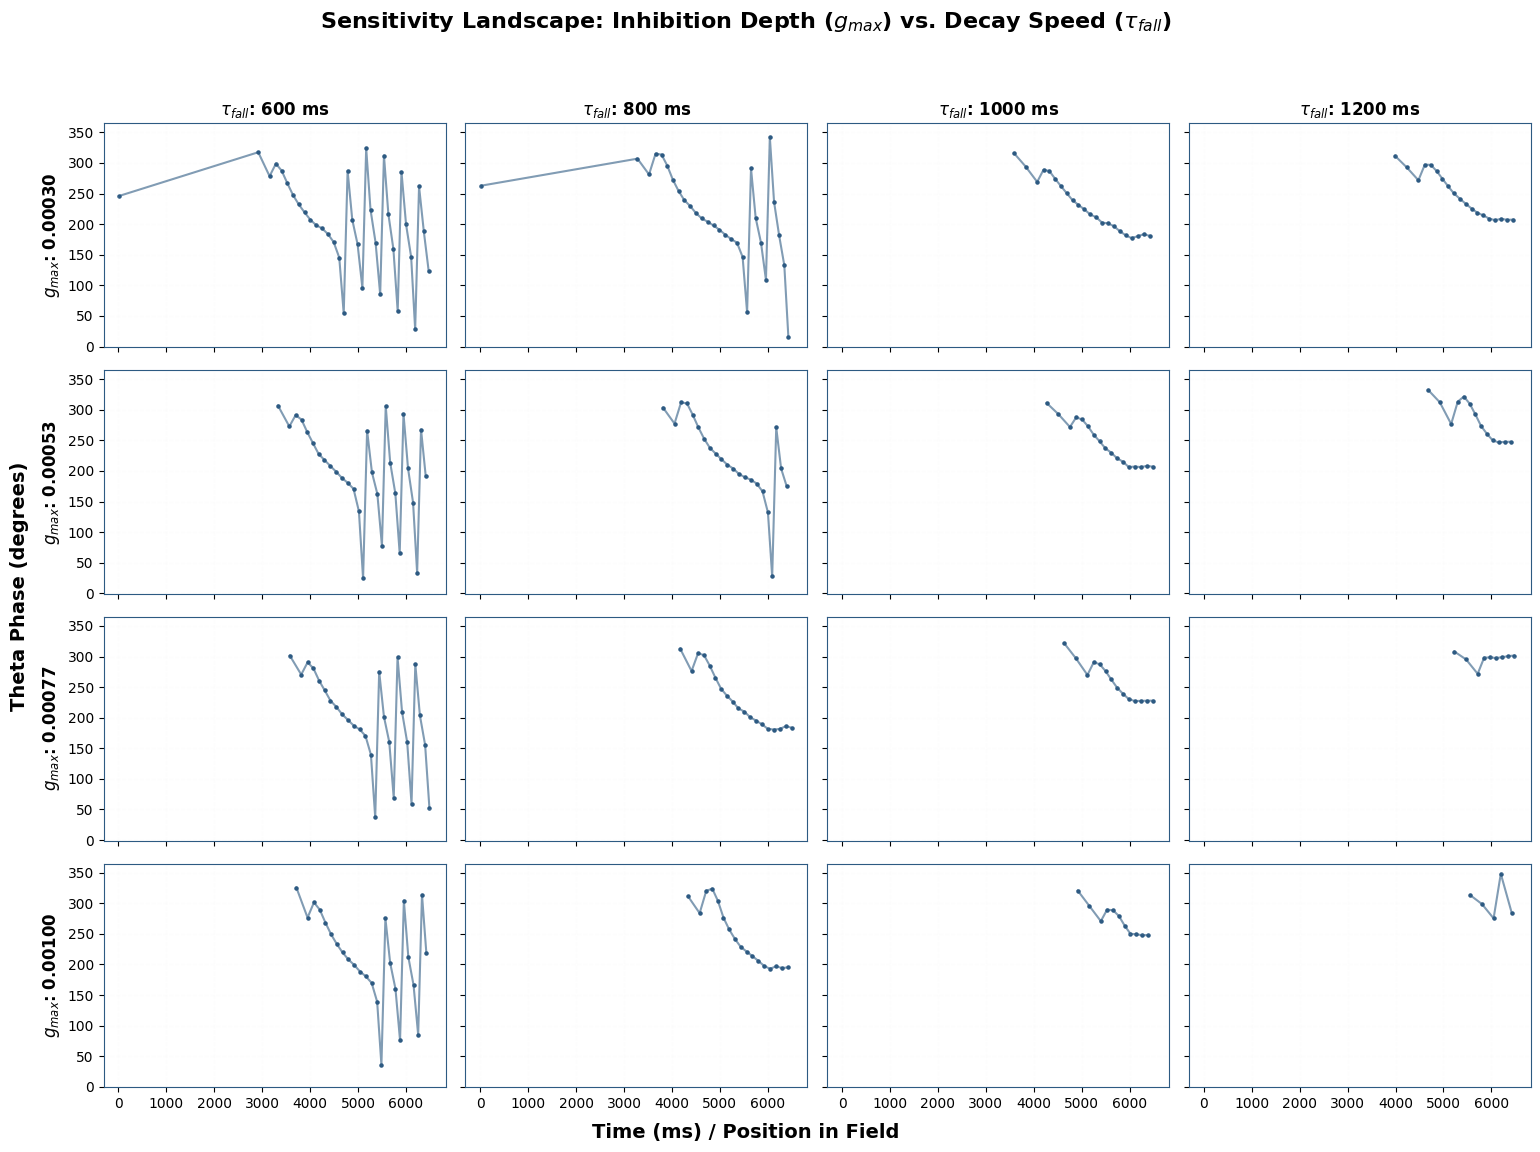

In [56]:
n_rows = len(g_max_array)
n_cols = len(tf_array)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3), 
                         sharex=True, sharey=True)

for i, gm_val in enumerate(g_max_array):
    for j, tf_val in enumerate(tf_array):
        ax = axes[i, j]
        res = results_matrix_gm[i * n_cols + j]
        
        # Plotting in degrees for easier interpretation (0-720 for wrap-around)
        ax.scatter(res['spikes'], np.degrees(res['phases']), color='#2D5A82', s=5, alpha=1)
        ax.plot(res['spikes'], np.degrees(res['phases']), color='#2D5A82', alpha=0.6)
        
        if i == 0:
            ax.set_title(f"$\\tau_{{fall}}$: {tf_val} ms", fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f"$g_{{max}}$: {gm_val:.5f}", fontsize=12, fontweight='bold')
        
        
        ax.grid(True, linestyle='--', alpha=0.1)
        
fig.text(0.5, 0.04, 'Time (ms) / Position in Field', ha='center', fontsize=14, fontweight='bold')
fig.text(0.04, 0.5, 'Theta Phase (degrees)', va='center', rotation='vertical', fontsize=14, fontweight='bold')
plt.suptitle("Sensitivity Landscape: Inhibition Depth ($g_{max}$) vs. Decay Speed ($\\tau_{fall}$)", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.savefig("final_figs/sensitivity_analysis_2.png",dpi=600)
plt.show()

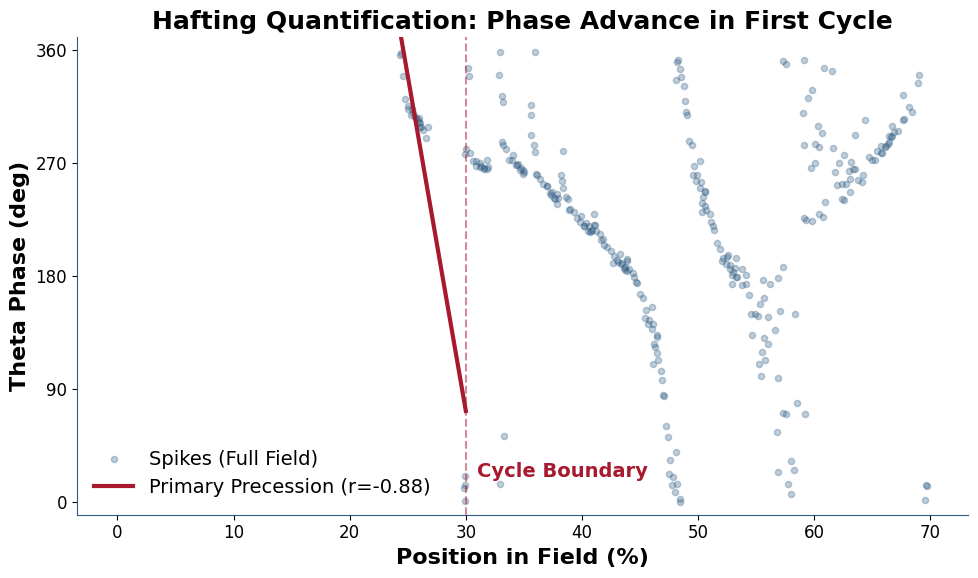

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def calculate_hafting_classic(all_spike_times, all_spike_phases, t_start=2000, t_end=6000, t_fit=3200):
    # 1. Filter ALL spikes for the plot
    mask = (all_spike_times >= t_start) & (all_spike_times <= t_end)
    field_spks = all_spike_times[mask]
    field_phases = np.degrees(all_spike_phases[mask])
    
    # Normalize position (0-100%) for the full field
    norm_pos = (field_spks - t_start) / (t_end - t_start) * 100
    
    # 2. Filter subset for the FIT (First Cycle)
    fit_mask = (field_spks <= t_fit)
    x_fit = (field_spks[fit_mask] - t_start) / (t_end - t_start) * 100
    p_fit = field_phases[fit_mask]

    best_r2 = -1
    stats = {}

    # 3. Rotate 360 degrees, but enforce NEGATIVE slope constraint
    for shift in range(360):
        shifted_p = (p_fit + shift) % 360
        slope, intercept, r_val, p_val, _ = linregress(x_fit, shifted_p)
        
        # CONSTRAINT: Only accept if slope is negative (precession)
        if slope < 0:
            if r_val**2 > best_r2:
                best_r2 = r_val**2
                stats = {
                    'slope': slope, 'r2': best_r2, 'r': r_val,
                    'shift': shift, 'intercept': intercept,
                    'cutoff_x': (t_fit - t_start) / (t_end - t_start) * 100
                }
                
    return stats, norm_pos, field_phases

# --- Plotting the "Clean vs. Raw" Dynamics ---
def plot_poster_precession(norm_pos, field_phases, stats):
    # Apply the shift to all spikes based on the first-cycle optimization
    aligned_phases = (field_phases + stats['shift']) % 360
    
    plt.figure(figsize=(10, 6))
    
    # 1. Display all spikes (showing the multi-cycle/ascending inadequacy)
    plt.scatter(norm_pos, aligned_phases, color='#2D5A82', alpha=0.3, s=20, label='Spikes (Full Field)')
    
    # 2. Display the fit line only for the first cycle
    x_line = np.linspace(0, stats['cutoff_x'], 100)
    y_line = stats['slope'] * x_line + stats['intercept']
    plt.plot(x_line, y_line, color='#A6192E', linewidth=3, 
             label=f"Primary Precession (r={stats['r']:.2f})")
    
    # 3. Visual breakdown marker
    plt.axvline(stats['cutoff_x'], color='#A6192E', linestyle='--', alpha=0.5)
    plt.text(stats['cutoff_x']+1, 20, "Cycle Boundary", color='#A6192E', fontweight='bold')

    plt.title("Hafting Quantification: Phase Advance in First Cycle", fontweight='bold')
    plt.xlabel("Position in Field (%)", fontweight='bold')
    plt.ylabel("Theta Phase (deg)", fontweight='bold')
    plt.ylim(-10, 370)
    plt.yticks([0, 90, 180, 270, 360])
    plt.legend(frameon=False)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# Execution
stats, n_pos, f_phases = calculate_hafting_classic(pooled_times, pooled_phases)
plot_poster_precession(n_pos, f_phases, stats)

In [578]:
num_runs = 20
spike_times_matrix = []
spike_phases_matrix =[]

gauss = False
theta = True

scale_array = np.linspace(0.8,1.1,num_runs)

for n in range(num_runs):

    cond_arr = np.full_like(time_arr,0.0)
    spike_times_stell.resize(0)
    stellate_0.soma(0.5).stellate_mech.ghbar = 0.0015*scale_array[n]

    curr_init_phase = np.random.uniform(0.0,2*np.pi)
    
    theta_factor = 1 + (mod_depth*(np.sin(curr_init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))

    if gauss:
        cond_arr = inhib_envelope 
    else : 
        cond_arr = inhib_base

    
    if theta:   
        cond_arr = cond_arr * theta_factor

    noise = np.random.normal(loc=0.0,scale=5e-6,size=len(inhib_cond_arr))
    
    cond_arr += noise
    cond_arr = np.maximum(cond_arr,0.00001)
    g_vec = h.Vector(cond_arr)
    g_vec.play(syn_inh._ref_g, h.dt)

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(sim_dur)

    temp_spikes = np.array(spike_times_stell.to_python())
    temp_phases = ((curr_init_phase+((temp_spikes) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

    spike_times_matrix.append(temp_spikes)
    spike_phases_matrix.append(temp_phases)

    spike_times_stell.resize(0)

/tmp/ipykernel_46710/3124417796.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')


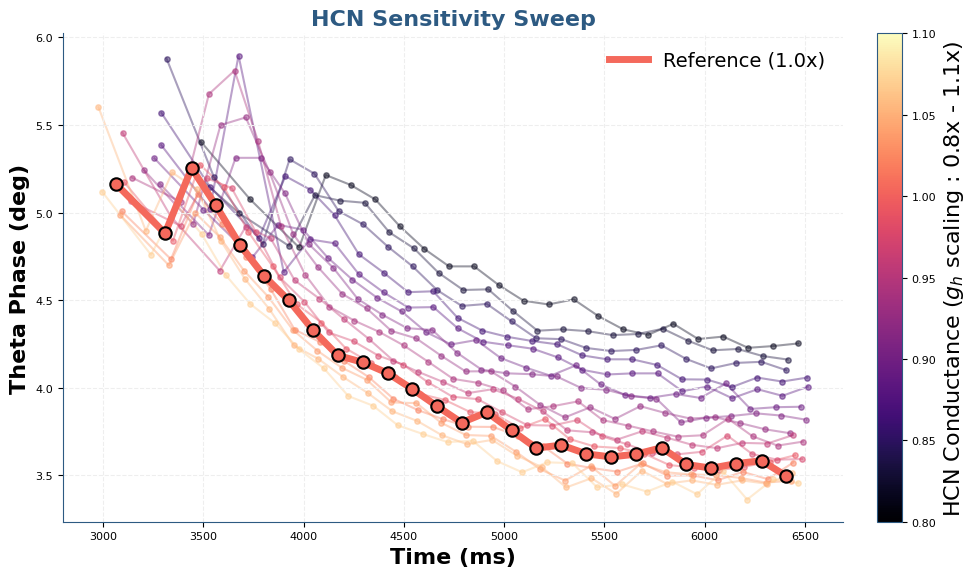

In [597]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Setup the Color Mapping
cmap = cm.get_cmap('magma')
norm = plt.Normalize(vmin=scale_array.min(), vmax=scale_array.max())
ref_scale = 1.0

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Iterate and Plot
for n in range(1, 18):
    scale = scale_array[n]
    color = cmap(norm(scale))
    
    # Check if this is our 1.0x reference
    is_reference = np.isclose(scale, ref_scale, atol=0.01)
    
    if is_reference:
        # High-impact Reference Line (Thick and on top)
        ax.plot(spike_times_matrix[n], spike_phases_matrix[n], 
                color=color, linewidth=5, zorder=10, label='Reference (1.0x)')
        # Add a white 'glow' or edge to the reference points to make them stand out
        ax.scatter(spike_times_matrix[n], spike_phases_matrix[n], 
                   color=color, s=80, zorder=11, edgecolor='black', linewidth=1.5)
    else:
        # Background Gradient Lines
        ax.plot(spike_times_matrix[n], spike_phases_matrix[n], 
                color=color, linewidth=1.5, alpha=0.4, zorder=1)
        ax.scatter(spike_times_matrix[n], spike_phases_matrix[n], 
                   color=color, s=15, alpha=0.5, zorder=2)

# 3. Add Colorbar for the gradient context
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('HCN Conductance ($g_h$ scaling : 0.8x - 1.1x)')

# 4. Poster Aesthetics
ax.set_title("HCN Sensitivity Sweep", 
             fontsize=16, fontweight='bold', color='#2D5A82')
ax.set_xlabel("Time (ms)", fontweight='bold')
ax.set_ylabel("Theta Phase (deg)", fontweight='bold')

ax.legend(frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=1)

plt.tight_layout()
plt.savefig("final_figs/hcn_sensitivity.png",dpi=600)
plt.show()